In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from astropy.io import fits
import pylab as plt

# Get labels, features, and create data set

In [ ]:
path_labels = "./labels.fits"
allstar = fits.open(path_labels)
labels = allstar[1].data

RGB = True
RGB = np.logical_and(RGB, labels['TEFF'] > 3500.)
RGB = np.logical_and(RGB, labels['TEFF'] < 5400.)
RGB = np.logical_and(RGB, labels['LOGG'] < 3.0)
RGB = np.logical_and(RGB, labels['LOGG'] > 0.0)
RGB = np.logical_and(RGB, labels['H'] < 10.5)

RGB_labels = labels[RGB]

rng = np.random.default_rng(17)
N_RGB = len(RGB_labels)
N_train, N_valid, N_test = 1024, 256, 512
I = rng.permutation(N_RGB)
I_train = I[0:N_train]
I_valid = I[N_train:N_train+N_valid]
I_test = I[N_train+N_valid:N_train+N_valid+N_test]

train_labels = RGB_labels[I_train]
valid_labels = RGB_labels[I_valid]
test_labels = RGB_labels[I_test]

train_labels_logg = train_labels['LOGG']
valid_labels_logg = valid_labels['LOGG']
test_labels_logg = test_labels['LOGG']
# print(train_labels_logg.shape) # (num_spectra, 1)

In [ ]:
train_features = np.load('./train_features.npy')
valid_features = np.load('./valid_features.npy')
test_features = np.load('./test_features.npy')


print(test_features.shape) # (num_spectra, num_pixels)

(512, 8575)


In [ ]:
# Convert training data into a dataset
X_train = torch.from_numpy(train_features).float()
train_logg_native = train_labels_logg.byteswap().newbyteorder()
y_train = torch.from_numpy(train_logg_native).float().view(-1, 1)
train_dataset = TensorDataset(X_train,y_train)

# Convert validation data to a dataset
X_valid = torch.from_numpy(valid_features).float()
valid_logg_native = valid_labels_logg.byteswap().newbyteorder()
y_valid = torch.from_numpy(valid_logg_native).float().view(-1, 1)
valid_dataset = TensorDataset(X_valid,y_valid)


X_test = torch.from_numpy(test_features).float()
test_logg_native = test_labels_logg.byteswap().newbyteorder()
y_test = torch.from_numpy(test_logg_native).float().view(-1, 1)
test_dataset = TensorDataset(X_test,y_test)

NUM_FEATURES = X_valid.shape[1]

# Linear Regression


In [ ]:
# HYPER paramaters to change 
LEARNING_RATE = 1e-3    
EPOCHS = 32
BATCH_SIZE = 32

SEED = 6

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)


dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Define model, loss, and optimizer
linear = nn.Linear(test_features.shape[1], 1)

loss_fn = nn.MSELoss() #Try nn.MSELoss(),  nn.L1Loss()
optimizer = optim.Adam(linear.parameters(), lr=LEARNING_RATE) #Try Adam or SGD

In [ ]:

# Define loss values for plotting purposes
PerEpochLoss = 0.0
train_loss = []
valid_loss = []


for epoch in range(EPOCHS):
    

    linear.train()  # train mode
    PerEpochLoss = 0.0
    for X,y in dataloader:
        optimizer.zero_grad()
        outputs = linear(X)

        loss = loss_fn(outputs, y)
        PerEpochLoss += loss.item()

        loss.backward()        

        optimizer.step()
    epoch_train_loss = PerEpochLoss/len(dataloader)
    train_loss.append(epoch_train_loss)

    # Calculate the loss on the entire validation dataset
    linear.eval() # validation mode
    PerEpochValidLoss = 0.0
    PerEpochLoss = 0.0
    with torch.no_grad():
        for val_X, val_y in valid_dataset:
            val_outputs = linear(val_X)
            val_loss = loss_fn(val_outputs, val_y)
            PerEpochValidLoss += val_loss.item()
    
    epoch_valid_loss = PerEpochValidLoss / len(valid_dataset)
    valid_loss.append(epoch_valid_loss)


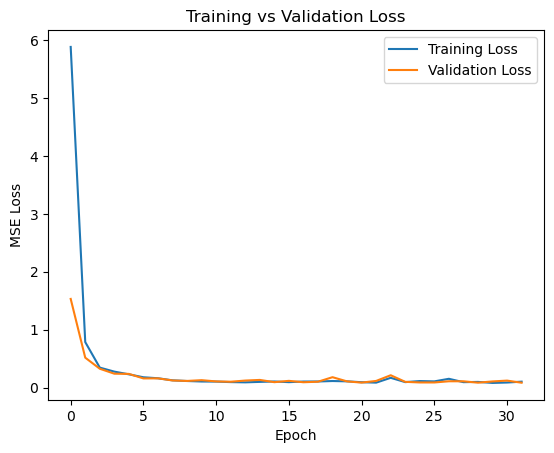

In [ ]:
# To plot the loss of the functions
plt.plot(range(EPOCHS), train_loss, label='Training Loss')
plt.plot(range(EPOCHS), valid_loss, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

RMSE:  0.28748686812708946


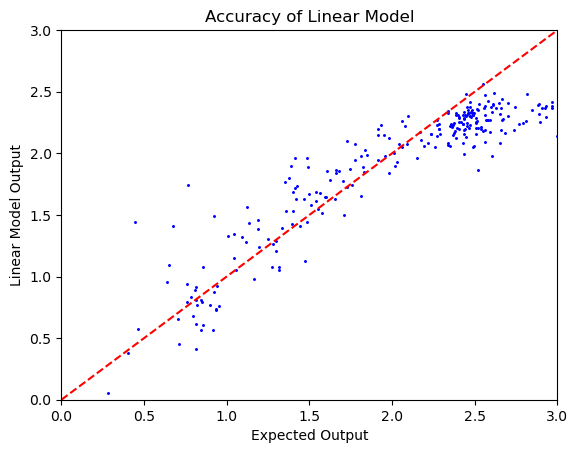

In [ ]:
# To plot the Model outputs of the validation data and the actual labels 
with torch.no_grad():
        acc = 0.0
        for val_X, val_y in valid_dataset:
            val_output = linear(val_X)
            plt.scatter(val_y.item(), val_output.item(), marker='.', color='blue', s=5)
            acc += (val_output.item() - val_y.item())**2
print("RMSE: ", np.sqrt(acc/len(valid_dataset)))
plt.xlabel("Expected Output")
plt.ylabel("Linear Model Output")
plt.title("Accuracy of Linear Model")
plt.xlim(0, 3.0)
plt.ylim(0, 3.0)
plt.plot([0, 3], [0, 3], color='red', linestyle='--')
plt.show()


# KNN

In [ ]:
# Define hyperparameters
NUM_NEAREST_NEIGHBORS= 5 #number of nearest neighbors
SEED = 72
def calculateDistances(point, datasetX): 
    #return torch.sum((point - datasetX)**2, axis = 1)
    return torch.sum(torch.abs(point - datasetX), dim=1)

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)



RMSE:  0.19477828022024413


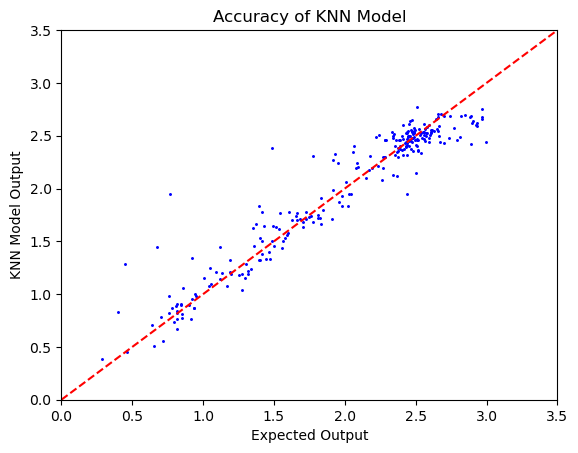

In [ ]:
valid_loss = []

# Because we have previously defined train_dataset = TensorDataset(X_train,y_train)
count = 0
acc = 0.0
for val_x, val_y in valid_dataset:
    #create matrix of distances of the validation points from the training data
    distances = calculateDistances(val_x, X_train)
    #find the indices of the k smallest distances
    knn = distances.topk(NUM_NEAREST_NEIGHBORS, largest=False)
    possible_labels = y_train[knn.indices]
    #take the average of the nearest points and make that the predicted label 
    val_output = sum(possible_labels)/NUM_NEAREST_NEIGHBORS

    plt.scatter(val_y.item(), val_output.item(), marker='.', color='blue', s=5)
    acc += (val_output.item() - val_y.item())**2

    #calculate MSE loss
    loss = (val_output - val_y)**2
    valid_loss.append(loss.item())

print("RMSE: ", np.sqrt(acc/len(valid_dataset)))
plt.xlabel("Expected Output")
plt.ylabel("KNN Model Output")
plt.title("Accuracy of KNN Model")
plt.xlim(0, 3.5)
plt.ylim(0, 3.5)
plt.plot([0, 3.5], [0, 3.5], color='red', linestyle='--')
plt.show()



/var/folders/vr/krfxbdzj66xclmv38bj33szc0000gn/T/ipykernel_24497/2597000113.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


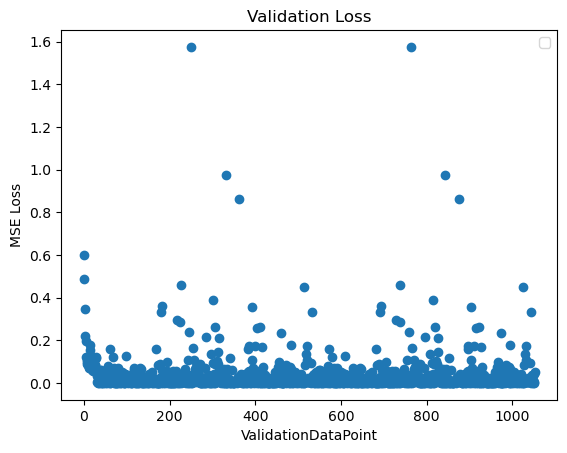

In [ ]:
#Plot the loss of the validation data
plt.scatter(range(len(valid_loss)), valid_loss)
plt.xlabel("ValidationDataPoint")
plt.ylabel("MSE Loss")
plt.title("Validation Loss")
plt.legend()
plt.show()


# MLP

In [ ]:
#Set HyperParameters
HIDDEN_LAYERS = [64, 32, 16]  # List of hidden layer sizes, e.g., [256, 128, 64] (starts with [32, 32])
ACTIVATION = nn.GELU      # Try: nn. ReLU nn.Tanh, nn.Sigmoid, nn.LeakyReLU, nn.GELU
SEED = 13

LEARNING_RATE = 1e-3            # Try: 1e-1, 1e-3, 5e-4
BATCH_SIZE = 32               # Try: 32, 64, 128, 256   
EPOCHS = 30                     # These are the number of times you do a batch


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
# MOST of the MLP code is from Clark's notes from recitation

In [ ]:
class MLP(nn.Module):
    """
    Multi-layer perceptron with configurable architecture.
    """
    
    def __init__(self, 
                 input_dim: int, 
                 hidden_layers: list, 
                 output_dim: int, 
                 activation: nn.Module):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(activation())
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        # No activation on output — CrossEntropyLoss expects raw logits
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        # Flatten image: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        return self.network(x)

In [ ]:
model = MLP(
        input_dim=NUM_FEATURES,
        hidden_layers=HIDDEN_LAYERS,
        output_dim=1,
        activation=ACTIVATION,
    )

loss_fn = nn.MSELoss() #Try MSELoss, L1Loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
model.train()  # Enable dropout, batch norm training mode, etc.
total_loss = 0.0

train_loss = []
valid_loss = []

for epoch in range(EPOCHS):
    total_loss_train = 0.0
    model.train()
    for data, target in train_loader:        
        # Forward pass
        output = model(data)
        loss = loss_fn(output, target)
        
        # Backward pass (compute gradients)
        optimizer.zero_grad()  # Clear gradients from previous step
        loss.backward()        # Backpropagation: ∂L/∂θ for all parameters
        optimizer.step()       # Update: θ → θ - η * ∂L/∂θ

        total_loss_train += loss.item()

    # Logging
    correct = 0
    total = 0
    total_loss_valid = 0.0
    model.eval()
    with torch.no_grad():
        for data_val, target_val in valid_loader:
            output_val = model(data_val)
            total_loss_valid += nn.MSELoss()(output_val, target_val).item() * target_val.size(0)
            _, predicted = torch.max(output_val, 1)
            correct += (predicted == target_val).sum().item()
            total += target_val.size(0)

    avg_loss_train = total_loss_train / len(train_loader)

    val_loss = total_loss_valid / total
    val_accuracy = 100.0 * correct / total
    
    train_loss.append(avg_loss_train)
    valid_loss.append(val_loss)




Accuracy:  0.3519081


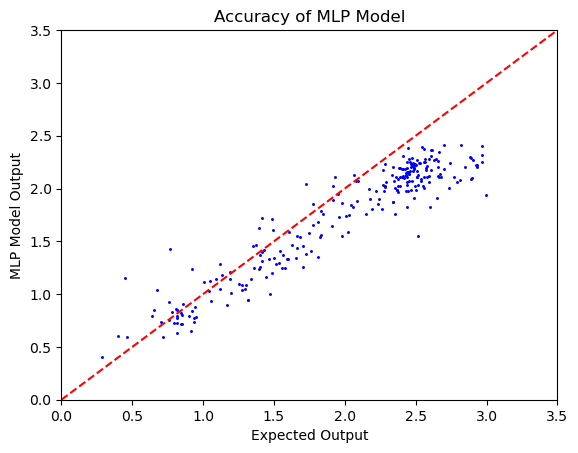

In [ ]:
acc = 0.0
with torch.no_grad():
    model.eval()
    val_output = model(X_valid)

    val_output_flat = val_output.squeeze().numpy()  # or .flatten()
    y_valid_flat = y_valid.squeeze().numpy()
    
    plt.scatter(y_valid_flat, val_output_flat, marker='.', color='blue', s=5)
    mse = np.mean((y_valid_flat - val_output_flat)**2)
    rmse = np.sqrt(mse)

    
print("Accuracy: ", rmse)

plt.xlabel("Expected Output")
plt.ylabel("MLP Model Output")
plt.title("Accuracy of MLP Model")
plt.xlim(0, 3.5)
plt.ylim(0, 3.5)
plt.plot([0, 3.5], [0, 3.5], color='red', linestyle='--')
plt.show()


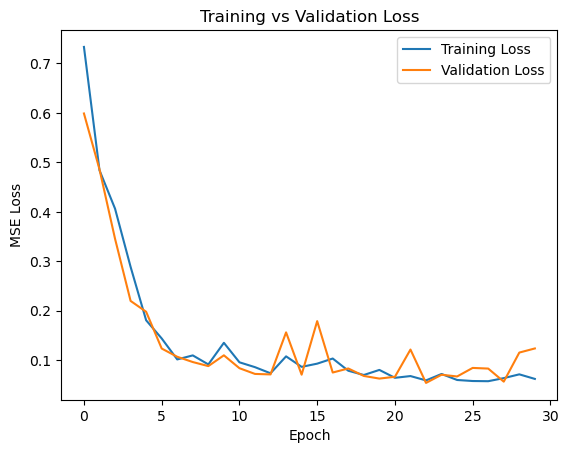

In [ ]:
#Plot the loss function over epochs trained
plt.plot(range(EPOCHS), train_loss, label='Training Loss')
plt.plot(range(EPOCHS), valid_loss, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Final Test! Using KNN with k = 5 and Distance = L1

RMSE:  0.27444432149919656


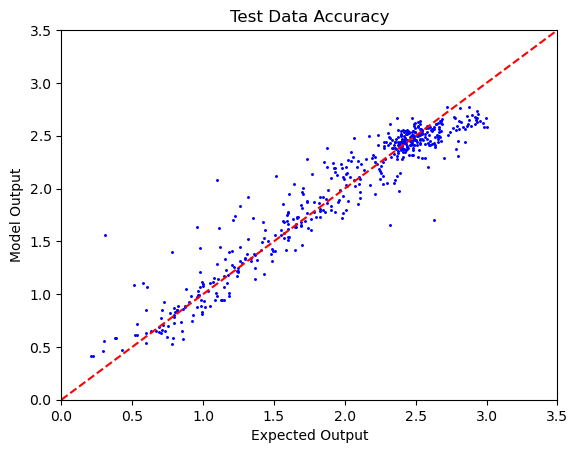

In [ ]:
count = 0
acc = 0.0
for val_x, val_y in test_dataset:
    #create matrix of distances of the validation points from the training data
    distances = calculateDistances(val_x, X_train)
    #find the indices of the k smallest distances
    knn = distances.topk(NUM_NEAREST_NEIGHBORS, largest=False)
    possible_labels = y_train[knn.indices]
    #take the average of the nearest points and make that the predicted label 
    val_output = sum(possible_labels)/NUM_NEAREST_NEIGHBORS

    plt.scatter(val_y.item(), val_output.item(), marker='.', color='blue', s=5)
    acc += (val_output.item() - val_y.item())**2

    #calculate MSE loss
    loss = (val_output - val_y)**2
    valid_loss.append(loss.item())

print("RMSE: ", np.sqrt(acc/len(valid_dataset)))
plt.xlabel("Expected Output")
plt.ylabel("Model Output")
plt.title("Test Data Accuracy")
plt.xlim(0, 3.5)
plt.ylim(0, 3.5)
plt.plot([0, 3.5], [0, 3.5], color='red', linestyle='--')
plt.show()

